In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from PIL import Image
import ctypes


## Étape 1 : Séparation de données linéairement séparables

In [2]:
X = np.array([
    [1, 1],
    [2, 3],
    [3, 3]
])

y = np.array([
    1, -1, -1
])


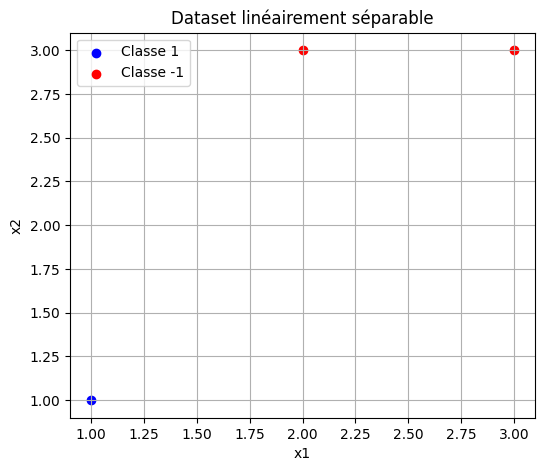

In [3]:
plt.figure(figsize=(6, 5))

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Classe 1",
    color="blue"
)

plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    label="Classe -1",
    color="red"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset linéairement séparable")
plt.legend()
plt.grid()

plt.show()


In [4]:
modele_lineaire = Perceptron(
    max_iter=1000,
    random_state=42
)

modele_lineaire.fit(X, y)

y_pred = modele_lineaire.predict(X)

print("Prédictions :", y_pred)
print("Vraies classes :", y)
print("Accuracy :", accuracy_score(y, y_pred))
print("itérations :", modele_lineaire.n_iter_)

Prédictions : [ 1 -1 -1]
Vraies classes : [ 1 -1 -1]
Accuracy : 1.0
itérations : 11


In [5]:
lib_etape1 = ctypes.CDLL("C-algorithms/ETAPE1.basicPerceptron.so")
lib_etape1.run_perceptron.restype = ctypes.c_int
erreurs = lib_etape1.run_perceptron()
print("Erreurs finales :", erreurs, "/ 3")


Erreurs finales : 0 / 3


## Étape 2 : Séparation de données non linéairement séparables

In [6]:
X_xor = np.array([
    [1, 0],
    [0, 1],
    [0, 0],
    [1, 1]
])

y_xor = np.array([
    1, 1, -1, -1
])

modele_perceptron = Perceptron(
    max_iter=1000,
    random_state=42
)

modele_perceptron.fit(X_xor, y_xor)

y_pred_xor = modele_perceptron.predict(X_xor)

print("Prédictions :", y_pred_xor)
print("Résultats attendus :", y_xor)
print("Comparaison entre les prédictions du modèle et le résultat attendu - Calcul du taux de fiabilité :", accuracy_score(y_xor, y_pred_xor))
print("Nombre d'itérations :", modele_perceptron.n_iter_)


Prédictions : [-1 -1 -1 -1]
Résultats attendus : [ 1  1 -1 -1]
Comparaison entre les prédictions du modèle et le résultat attendu - Calcul du taux de fiabilité : 0.5
Nombre d'itérations : 9


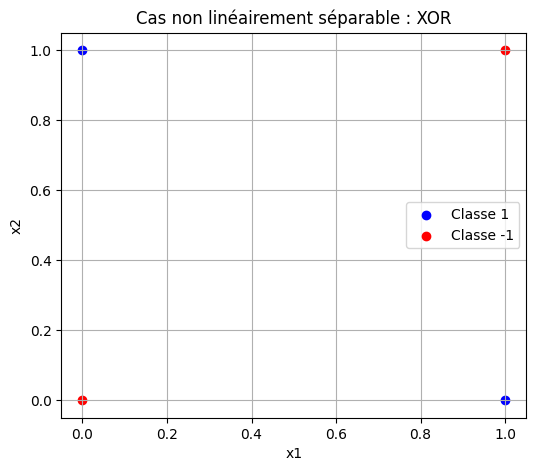

In [7]:
plt.figure(figsize=(6, 5))

plt.scatter(
    X_xor[y_xor == 1, 0],
    X_xor[y_xor == 1, 1],
    color="blue",
    label="Classe 1"
)

plt.scatter(
    X_xor[y_xor == -1, 0],
    X_xor[y_xor == -1, 1],
    color="red",
    label="Classe -1"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Cas non linéairement séparable : XOR")
plt.legend()
plt.grid()
plt.show()


In [8]:
lib = ctypes.CDLL('C-algorithms/ETAPE2.xor.so')

lib.run_xor_brut.restype = ctypes.c_int
lib.run_xor_transforme.restype = ctypes.c_int

erreurs_brut = lib.run_xor_brut()
erreurs_transforme = lib.run_xor_transforme()

print("XOR brut - erreurs :", erreurs_brut)    
print("XOR transformé - erreurs :", erreurs_transforme)

XOR brut - erreurs : 2
XOR transformé - erreurs : 0


## Étape 3 : Transformation des images en vecteurs

In [9]:
dataset_path = "dataset-img"

classes = ["plastic", "verre", "metal"] 
""" 3 classes indexes: 0, 1, 2 """

IMG_SIZE = (64, 64)

X = []
y = []

for class_index, classe in enumerate(classes):
    classe_path = os.path.join(dataset_path, classe)
    for fichier in os.listdir(classe_path):
        if fichier.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            image_path = os.path.join(classe_path, fichier)
            try:
                image = Image.open(image_path).convert("RGB")
                image = image.resize(IMG_SIZE)
                image_array = np.array(image)
                image_array = image_array / 255.0
                image_vector = image_array.flatten()
                X.append(image_vector)
                y.append(class_index)

            except Exception as e:
                print("Erreur avec :", image_path, e)

X = np.array(X)
y = np.array(y)

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)
print("Nombre total d'images :", len(X))

print("\nNombre de caractéristiques par image :", X.shape[1])


Forme de X : (17, 12288)
Forme de y : (17,)
Nombre total d'images : 17

Nombre de caractéristiques par image : 12288


## Étape 3 : Entraînement du PMC avec un jeu de données déchet (trois classes)

In [10]:
# Séparation entraînement / test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Images d'entraînement :", len(X_train))
print("Images de test :", len(X_test))

# Création du PMC
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam", 
    max_iter=500,
    random_state=42
)
""" 

* adam 
adam est le nom d'un algorithme d'optimisation. Le réseau cherche à minimiser l'erreur entre la prédiction et le résultat attendu. adam est une méthode 
d'optimisation couramment utilisée pour les réseaux de neurones et qui fonctionne généralement bien sans avoir besoin de régler énormément de paramètres.

* 500 
maximum de 500 itérations d'apprentissage.

* 42 
random_state = 42 : permet de rendre le hasard reproductible.

"""

# Entraînement
mlp.fit(X_train, y_train)

# Prédictions
y_pred = mlp.predict(X_test)

# Résultats
print("Accuracy :", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))


Images d'entraînement : 13
Images de test : 4
Accuracy : 0.75
              precision    recall  f1-score   support

     plastic       1.00      1.00      1.00         2
       verre       0.00      0.00      0.00         1
       metal       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.50      0.67      0.56         4
weighted avg       0.62      0.75      0.67         4



/home/fatima/Projet-annuel-3JIABD/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fatima/Projet-annuel-3JIABD/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fatima/Projet-annuel-3JIABD/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

Vérification sur cas de test (implémentation C) — le MLP ci-dessus (sklearn) est entraîné sur le vrai dataset ; ci-dessous, notre implémentation C est validée sur des exemples de test fixes avant d'être appliquée au dataset.

In [11]:
lib_pmc = ctypes.CDLL("C-algorithms/ETAPE3.multiLayersPerceptron.so")
lib_pmc.run_pmc.restype = ctypes.c_int
bonnes_predictions = lib_pmc.run_pmc()
print("Bonnes predictions :", bonnes_predictions, "/ 3")

Bonnes predictions : 3 / 3


In [12]:
def image_vers_vecteur(chemin, taille=(2, 2)):
    img = Image.open(chemin).convert("RGB")
    img = img.resize(taille)
    array = np.array(img) / 255.0
    return array.flatten()

In [13]:
lib_etape1.run_perceptron_dataset.restype = ctypes.c_int
lib_etape1.run_perceptron_dataset.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int),
    ctypes.c_int,
]

vecteurs = np.array([
    image_vers_vecteur("dataset-img/plastic/01.jpg"),
    image_vers_vecteur("dataset-img/plastic/02.jpeg"),
    image_vers_vecteur("dataset-img/metal/02.jpeg"),
    image_vers_vecteur("dataset-img/metal/03.jpeg"),
], dtype=np.float64)

labels = np.array([-1, -1, 1, 1], dtype=np.int32)

vecteurs_c = vecteurs.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
labels_c = labels.ctypes.data_as(ctypes.POINTER(ctypes.c_int))

erreurs = lib_etape1.run_perceptron_dataset(vecteurs_c, labels_c, len(labels))
print("Erreurs sur le dataset reel :", erreurs, "/", len(labels))


Erreurs sur le dataset reel : 0 / 4


In [14]:
lib_pmc.run_pmc_dataset.restype = ctypes.c_int
lib_pmc.run_pmc_dataset.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int),
    ctypes.c_int,
]

vecteurs_pmc = np.array([
    image_vers_vecteur("dataset-img/plastic/01.jpg"),
    image_vers_vecteur("dataset-img/plastic/02.jpeg"),
    image_vers_vecteur("dataset-img/verre/01.jpeg"),
    image_vers_vecteur("dataset-img/verre/02.jpeg"),
    image_vers_vecteur("dataset-img/metal/02.jpeg"),
    image_vers_vecteur("dataset-img/metal/03.jpeg"),
], dtype=np.float64)

classes_pmc = np.array([0, 0, 1, 1, 2, 2], dtype=np.int32)  # 0=plastique, 1=verre, 2=metal

vecteurs_pmc_c = vecteurs_pmc.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
classes_pmc_c = classes_pmc.ctypes.data_as(ctypes.POINTER(ctypes.c_int))

bonnes = lib_pmc.run_pmc_dataset(vecteurs_pmc_c, classes_pmc_c, len(classes_pmc))
print("Bonnes predictions sur le dataset reel :", bonnes, "/", len(classes_pmc))


Bonnes predictions sur le dataset reel : 6 / 6
